# Pediatric Pneumonia Detection from Chest X-Ray Images
**Course / Assignment:** Problem Set 01  
**Objective:** Develop and evaluate a Convolutional Neural Network (CNN) to classify pediatric chest X-rays (anterior-posterior view) into `NORMAL` and `PNEUMONIA`.

In [2]:
import os
import zipfile
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print(f"\nTensorFlow Version: {tf.__version__}")
gpu_devices = tf.config.list_physical_devices('GPU')
print(f"Hardware Accelerator: {'GPU detected (' + tf.test.gpu_device_name() + ')' if gpu_devices else 'CPU (Tip: Switch to T4 GPU in Runtime > Change runtime type)'}")

Mounted at /content/drive

TensorFlow Version: 2.20.0
Hardware Accelerator: GPU detected (/device:GPU:0)


In [3]:
import os
import zipfile

def find_or_extract_dataset(search_root="/content/drive/MyDrive"):
    print(f"Scanning '{search_root}' for dataset folder or archives...")

    # 1. Check if an extracted directory already exists with 'train' and subfolders 'NORMAL' / 'PNEUMONIA'
    for root, dirs, _ in os.walk(search_root):
        if 'train' in dirs:
            train_sub = os.path.join(root, 'train')
            if os.path.exists(os.path.join(train_sub, 'NORMAL')) or os.path.exists(os.path.join(train_sub, 'PNEUMONIA')):
                print(f"Found existing dataset directory at: {root}")
                return root

    # 2. Check for zip files in Google Drive if no raw directory is found
    zip_candidates = []
    for root, _, files in os.walk(search_root):
        for f in files:
            if f.lower().endswith('.zip') and any(keyword in f.lower() for keyword in ['xray', 'chest', 'pneumonia', 'problem']):
                zip_candidates.append(os.path.join(root, f))

    if zip_candidates:
        chosen_zip = zip_candidates[0]
        extract_to = "/content/chest_xray_extracted"
        print(f"Found archive: {chosen_zip}")
        print(f"Extracting to local disk ({extract_to}) for high-speed I/O...")
        os.makedirs(extract_to, exist_ok=True)
        with zipfile.ZipFile(chosen_zip, 'r') as z:
            z.extractall(extract_to)

        # Locate the train folder inside extracted files
        for root, dirs, _ in os.walk(extract_to):
            if 'train' in dirs:
                return root

    # 3. Fallback: check if loose images exist in MyDrive and structure them
    print("Direct folder structure not detected immediately. Checking /content/drive/MyDrive contents:")
    top_level = os.listdir(search_root)
    print("Files/Folders found in Drive:", top_level[:15])
    return None

BASE_DIR = find_or_extract_dataset()

# If manual override is needed, set it here:
# BASE_DIR = '/content/drive/MyDrive/path_to_your_dataset'

if BASE_DIR and os.path.exists(BASE_DIR):
    print(f"\nBASE_DIR successfully set to: {BASE_DIR}")
    print("Folders inside BASE_DIR:", os.listdir(BASE_DIR))
else:
    raise FileNotFoundError("Could not automatically locate the dataset in Google Drive. Please confirm the folder name in MyDrive.")

Scanning '/content/drive/MyDrive' for dataset folder or archives...
Found existing dataset directory at: /content/drive/MyDrive/problem 1/New folder (2)

BASE_DIR successfully set to: /content/drive/MyDrive/problem 1/New folder (2)
Folders inside BASE_DIR: ['val', '__MACOSX', 'test', 'train']


Dataset Distribution:


,NORMAL,PNEUMONIA
Train,1362,3932
Val,8,8
Test,234,393


<Figure size 800x400 with 0 Axes>

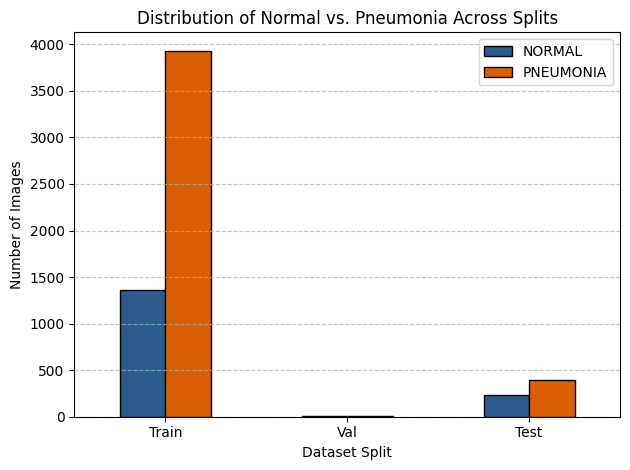

In [4]:
def get_class_counts(folder_path):
    counts = {}
    for label in ['NORMAL', 'PNEUMONIA']:
        path = os.path.join(folder_path, label)
        counts[label] = len([f for f in os.listdir(path) if not f.startswith('.')]) if os.path.exists(path) else 0
    return counts

train_counts = get_class_counts(os.path.join(BASE_DIR, 'train'))
val_counts   = get_class_counts(os.path.join(BASE_DIR, 'val'))
test_counts  = get_class_counts(os.path.join(BASE_DIR, 'test'))

df_counts = pd.DataFrame([train_counts, val_counts, test_counts], index=['Train', 'Val', 'Test'])
print("Dataset Distribution:")
display(df_counts)

# Visualize class distribution
plt.figure(figsize=(8, 4))
df_counts.plot(kind='bar', color=['#2b5c8f', '#d95f02'], edgecolor='black')
plt.title('Distribution of Normal vs. Pneumonia Across Splits', fontsize=12)
plt.ylabel('Number of Images', fontsize=10)
plt.xlabel('Dataset Split', fontsize=10)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

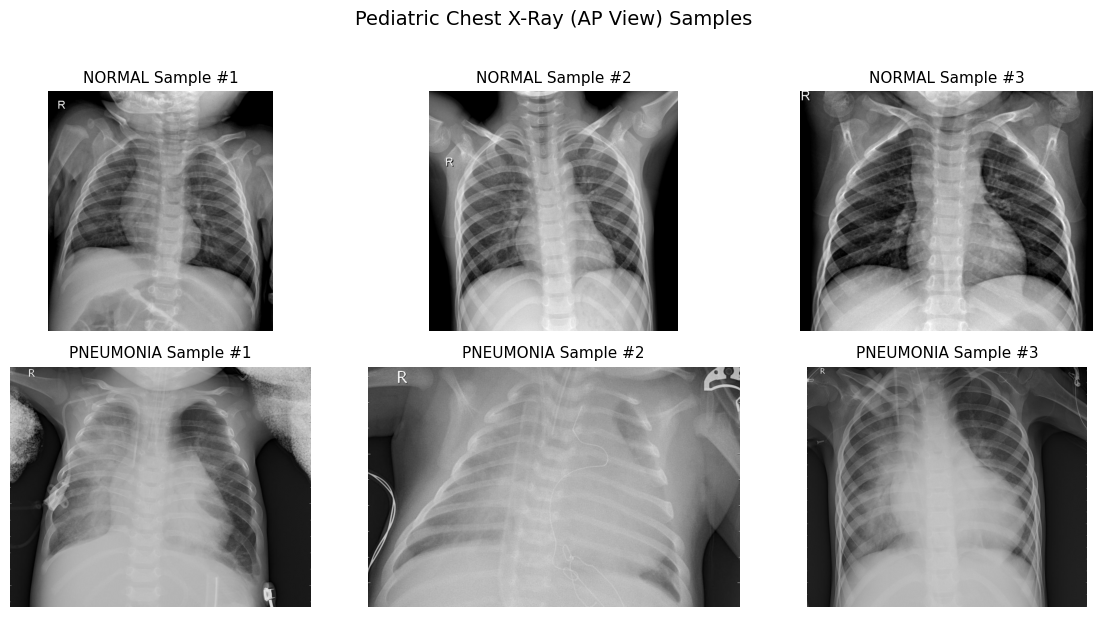

In [5]:
def plot_sample_images(base_dir, num_samples=3):
    fig, axes = plt.subplots(2, num_samples, figsize=(12, 6))
    for row_idx, category in enumerate(['NORMAL', 'PNEUMONIA']):
        folder = os.path.join(base_dir, 'train', category)
        sample_files = [f for f in os.listdir(folder) if not f.startswith('.')][:num_samples]
        for col_idx, file_name in enumerate(sample_files):
            img_path = os.path.join(folder, file_name)
            img = Image.open(img_path)
            ax = axes[row_idx, col_idx]
            ax.imshow(img, cmap='gray')
            ax.set_title(f"{category} Sample #{col_idx+1}", fontsize=11)
            ax.axis('off')
    plt.suptitle("Pediatric Chest X-Ray (AP View) Samples", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

plot_sample_images(BASE_DIR)

In [7]:
IMG_HEIGHT, IMG_WIDTH = 224, 224
BATCH_SIZE = 64  # Optimal for T4 GPU

# Build Datasets
if val_counts['NORMAL'] + val_counts['PNEUMONIA'] < 50:
    print("Generating 80-20 train/validation split from 'train'...")
    train_ds = tf.keras.utils.image_dataset_from_directory(
        os.path.join(BASE_DIR, 'train'),
        validation_split=0.2,
        subset="training",
        seed=SEED,
        image_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        label_mode='binary'
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        os.path.join(BASE_DIR, 'train'),
        validation_split=0.2,
        subset="validation",
        seed=SEED,
        image_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        label_mode='binary'
    )
else:
    train_ds = tf.keras.utils.image_dataset_from_directory(
        os.path.join(BASE_DIR, 'train'),
        image_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        label_mode='binary',
        shuffle=True,
        seed=SEED
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        os.path.join(BASE_DIR, 'val'),
        image_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        label_mode='binary',
        shuffle=False
    )

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, 'test'),
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False
)

# Compute Class Weights INSTANTLY using counts (no image loading)
total_train = train_counts['NORMAL'] + train_counts['PNEUMONIA']
class_weights = {
    0: total_train / (2.0 * max(train_counts['NORMAL'], 1)),
    1: total_train / (2.0 * max(train_counts['PNEUMONIA'], 1))
}
print(f"\nInstant Class Weights (0=NORMAL, 1=PNEUMONIA): {class_weights}")

# In-Memory Cache & Prefetching
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Generating 80-20 train/validation split from 'train'...
Found 5294 files belonging to 2 classes.
Using 4236 files for training.
Found 5294 files belonging to 2 classes.
Using 1058 files for validation.
Found 627 files belonging to 2 classes.

Instant Class Weights (0=NORMAL, 1=PNEUMONIA): {0: 1.9434654919236416, 1: 0.6731943031536114}


In [8]:
def build_chest_xray_cnn(input_shape=(224, 224, 3)):
    # Data augmentation tailored to medical imaging (avoids vertical flips to preserve lung anatomy)
    data_augmentation = tf.keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.05),
    ], name="clinical_augmentation")

    model = models.Sequential([
        layers.Input(shape=input_shape),
        data_augmentation,
        layers.Rescaling(1./255),

        # Conv Block 1
        layers.Conv2D(32, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2, 2)),

        # Conv Block 2
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2, 2)),

        # Conv Block 3
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2, 2)),

        # Conv Block 4
        layers.Conv2D(256, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2, 2)),

        # Classification Head
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(1, activation='sigmoid')
    ], name="Pediatric_Pneumonia_CNN")

    return model

model = build_chest_xray_cnn()
model.summary()

Model: "Pediatric_Pneumonia_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ clinical_augmentation           │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 423,873 (1.62 MB)

 Trainable params: 422,657 (1.61 MB)

 Non-trainable params: 1,216 (4.75 KB)

In [10]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

training_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath='best_pneumonia_cnn.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

EPOCHS = 25

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=training_callbacks
)

Epoch 1/25
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - accuracy: 0.9183 - auc: 0.9687 - loss: 0.2239 - precision: 0.9747 - recall: 0.9118
Epoch 1: val_loss improved from None to 0.75976, saving model to best_pneumonia_cnn.keras

Epoch 1: finished saving model to best_pneumonia_cnn.keras
67/67 ━━━━━━━━━━━━━━━━━━━━ 25s 281ms/step - accuracy: 0.9315 - auc: 0.9781 - loss: 0.1854 - precision: 0.9781 - recall: 0.9280 - val_accuracy: 0.7637 - val_auc: 0.9498 - val_loss: 0.7598 - val_precision: 0.7630 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/25
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 0.9419 - auc: 0.9870 - loss: 0.1462 - precision: 0.9824 - recall: 0.9372
Epoch 2: val_loss did not improve from 0.75976
67/67 ━━━━━━━━━━━━━━━━━━━━ 18s 266ms/step - accuracy: 0.9474 - auc: 0.9871 - loss: 0.1429 - precision: 0.9827 - recall: 0.9453 - val_accuracy: 0.7609 - val_auc: 0.5310 - val_loss: 1.8651 - val_precision: 0.7609 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/25
67/67 

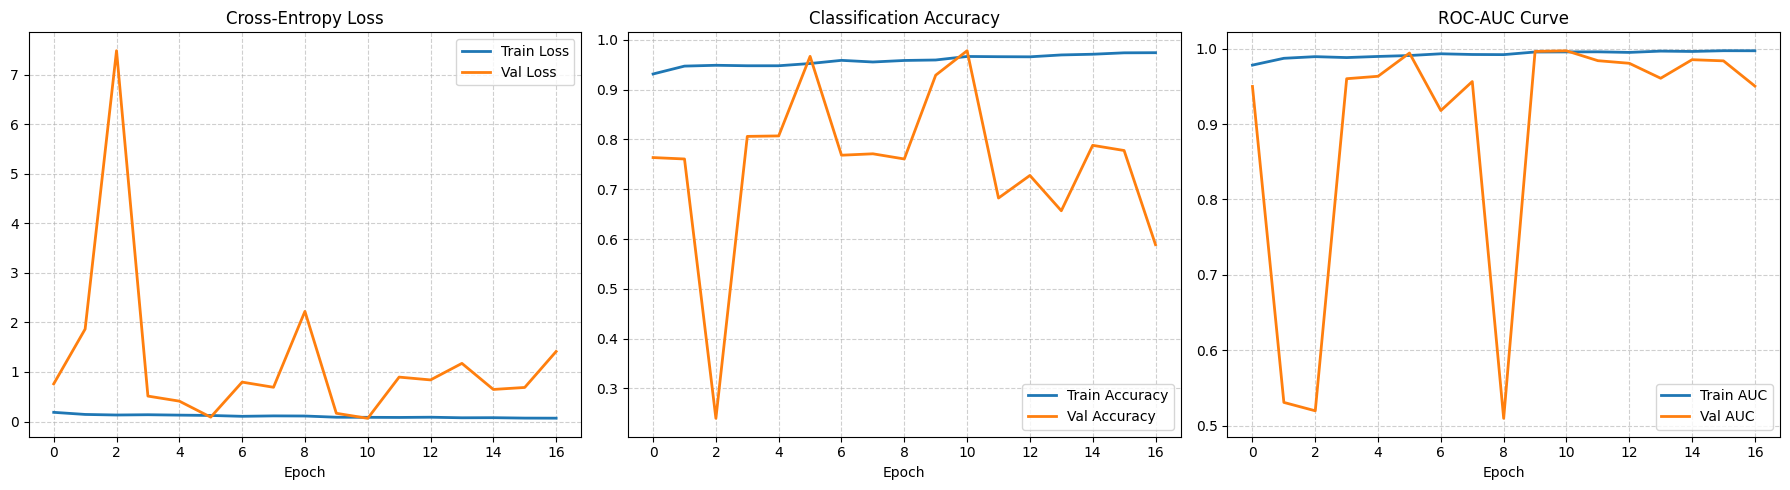

In [11]:
def plot_training_curves(history):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Loss
    axes[0].plot(history.history['loss'], label='Train Loss', lw=2)
    axes[0].plot(history.history['val_loss'], label='Val Loss', lw=2)
    axes[0].set_title('Cross-Entropy Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.6)

    # Accuracy
    axes[1].plot(history.history['accuracy'], label='Train Accuracy', lw=2)
    axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', lw=2)
    axes[1].set_title('Classification Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.6)

    # AUC
    axes[2].plot(history.history['auc'], label='Train AUC', lw=2)
    axes[2].plot(history.history['val_auc'], label='Val AUC', lw=2)
    axes[2].set_title('ROC-AUC Curve')
    axes[2].set_xlabel('Epoch')
    axes[2].legend()
    axes[2].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

plot_training_curves(history)

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 144ms/step

             CLINICAL CLASSIFICATION REPORT
              precision    recall  f1-score   support

      NORMAL     0.9545    0.3590    0.5217       234
   PNEUMONIA     0.7217    0.9898    0.8348       393

    accuracy                         0.7544       627
   macro avg     0.8381    0.6744    0.6783       627
weighted avg     0.8086    0.7544    0.7179       627



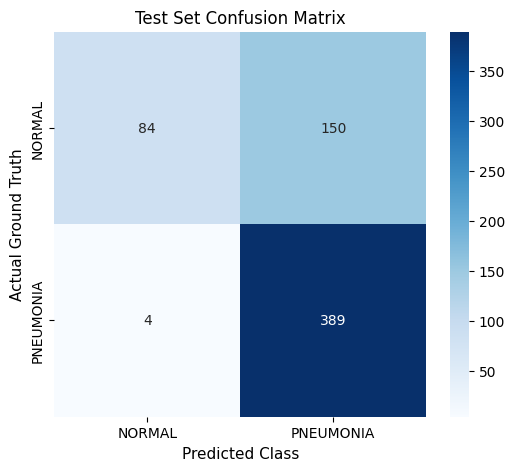

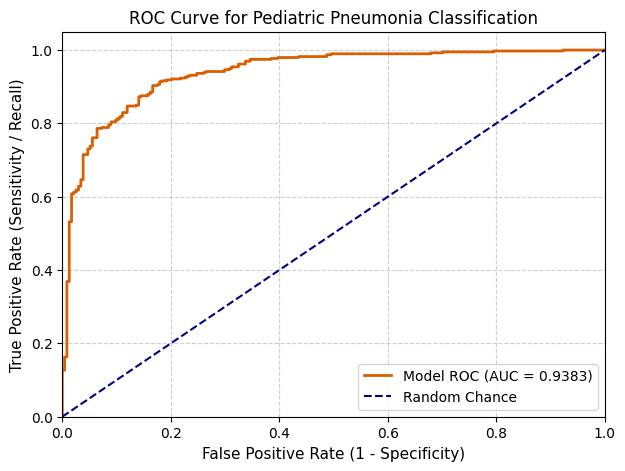

In [12]:
# Extract ground truth and predicted probabilities
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0).flatten()
y_pred_probs = model.predict(test_ds).flatten()
y_pred = (y_pred_probs >= 0.5).astype(int)

class_names = ['NORMAL', 'PNEUMONIA']

# Classification Report
print("\n" + "="*55)
print("             CLINICAL CLASSIFICATION REPORT")
print("="*55)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Class', fontsize=11)
plt.ylabel('Actual Ground Truth', fontsize=11)
plt.title('Test Set Confusion Matrix', fontsize=12)
plt.show()

# Receiver Operating Characteristic (ROC) Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc_score = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#d95f02', lw=2, label=f'Model ROC (AUC = {roc_auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11)
plt.title('ROC Curve for Pediatric Pneumonia Classification', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Clinical Discussion & Healthcare Analysis:

1. **Prioritizing Recall (Sensitivity):**
   - In pediatric radiography, a **False Negative** (diagnosing a child with pneumonia as healthy) is clinically dangerous as it delays antibiotic or supportive treatment. A **False Positive** merely leads to a secondary clinical review. Thus, high recall for the `PNEUMONIA` class is essential.
2. **Handling Class Imbalance:**
   - The training set possesses a ~3:1 ratio of pneumonia to normal scans. Utilizing balanced `class_weight` during compilation prevents the gradient updates from prioritizing the majority class.
3. **Domain-Specific Augmentation:**
   - Chest X-rays have fixed vertical orientation (clavicles and trachea at the top, diaphragm at the base). Augmentation restricts transformations to small rotations, slight zooms, and horizontal flips, strictly avoiding vertical flips to preserve anatomical validity.